In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
from dotenv import load_dotenv; load_dotenv()

True

In [ ]:
# !{sys.executable} -m pip install -U langgraph langgraph-checkpoint langgraph-checkpoint-sqlite langchain-core langchain-openai

In [3]:
# from poliprompt import TextClassifier,MultiModalClassifier
from poliprompt import MultiModalClassifier

2026-03-07 23:43:58,176 - faiss.loader - INFO - Loading faiss with AVX2 support.
2026-03-07 23:43:58,203 - faiss.loader - INFO - Successfully loaded faiss with AVX2 support.
d:\PoliPrompt-main\poliprompt_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# data_file = "../examples/topic_data.csv"
data_file = "../examples/HatefulMemes/train.jsonl"
work_station = "../examples/TopicExperiment"
env_path = "../.env"
options = ['1', '0']
image_dir="../examples/HatefulMemes"
feature_col = "text"
answer_col = "label"
image_col="img"
random_state = 42
requests_per_period = 60
seconds_per_period = 60

In [5]:
import logging

# 配置日志格式
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
# 在 Notebook 环境里创建一个 logger
logger = logging.getLogger("Notebook")

In [6]:
topic_classifier = MultiModalClassifier(data_file, work_station, env_path, options, image_col=image_col, image_dir=image_dir)
logger.info("Running in Multi-Modal Mode.")

2026-03-07 23:44:11,263 - Notebook - INFO - Running in Multi-Modal Mode.


In [7]:
embedding_llm_name = "qwen"
reduce_method = "umap"
select_method = "kmeans"
testing = False
testing_size = 128
kshots = 3
lambda_param = 0.5

In [ ]:
# topic_classifier.create_few_shot_pool(embedding_llm_name, reduce_method, select_method, testing=False)

2026-03-06 23:18:30,026 - poliprompt.multimodal_classifier - WARNING - You are supposed to provide 'embedding_llm_configs.json', 'reduce_configs.json', and 'select_configs.json' in the path ..\examples\TopicExperiment\infiles\configs
2026-03-06 23:18:41,366 - poliprompt.llm_contribs - INFO - 线程 14548：已完成 6 - 10 / 8500 的 Embedding
2026-03-06 23:18:41,483 - poliprompt.llm_contribs - INFO - 线程 14548：已完成 26 - 30 / 8500 的 Embedding
2026-03-06 23:18:41,536 - poliprompt.llm_contribs - INFO - 线程 14548：已完成 46 - 50 / 8500 的 Embedding
2026-03-06 23:18:41,654 - poliprompt.llm_contribs - INFO - 线程 14548：已完成 31 - 35 / 8500 的 Embedding
2026-03-06 23:18:41,664 - poliprompt.llm_contribs - INFO - 线程 14548：已完成 56 - 60 / 8500 的 Embedding
2026-03-06 23:18:41,716 - poliprompt.llm_contribs - INFO - 线程 14548：已完成 41 - 45 / 8500 的 Embedding
2026-03-06 23:18:41,827 - poliprompt.llm_contribs - INFO - 线程 14548：已完成 11 - 15 / 8500 的 Embedding
2026-03-06 23:18:42,039 - poliprompt.llm_contribs - INFO - 线程 14548：已完成 16

In [8]:
llm_name = "gpt-4o-mini"
prompt_file_name = "hateful_v1.txt"

In [9]:
enhanced_description = topic_classifier.optimize_task_description(llm_name, prompt_file_name)

Mapping: 100%|██████████| 256/256 [16:23<00:00,  3.84s/it]


--- PHASE 2 (REDUCE): Synthesizing Global Knowledge ---


2026-03-07 20:36:23,428 - poliprompt.multimodal_classifier - INFO - Map-Reduce Optimization completed successfully.


In [10]:
enhanced_description

'### CONCISE SUMMARY RULES\n\n#### HATEFUL (Label: 1)\n**Key Characteristics:**\n- **Direct Attacks on Protected Groups:** Content that explicitly targets individuals or groups based on race, religion, ethnicity, nationality, immigration status, caste, sex, gender identity, sexual orientation, or disability.\n- **Dehumanizing Language:** Use of terms or phrases that reduce individuals or groups to inferior statuses, often comparing them to animals or objects.\n- **Violent or Threatening Statements:** Content that promotes violence or suggests harm against a protected group.\n- **Stereotyping:** Generalizations that perpetuate harmful stereotypes about a protected group, implying inferiority or criminality.\n\n**Typical Patterns:**\n- Use of derogatory terms or slurs.\n- References to historical atrocities or violent acts in a trivializing manner.\n- Implicit or explicit calls for exclusion or segregation based on identity.\n- Mocking or belittling individuals based on their characteris

In [9]:
llm_a_name = "gpt-4o-mini"
# llm_b_name = "gemini-1.5-flash-latest"
# llm_b_name = "claude-3-haiku-20240307"
# llm_b_name = "gpt-4o-mini"
llm_b_name = "qwen-vl-max"
llm_adv_name = "gpt-4o"

In [10]:
testing = True
testing_size = 128

--- 🚀 Agentic System Ready ---
Library Size: 8500 | Task Queue: 128

--- [Row 126] HUMAN INTERVENTION REQUIRED ---
Logic: AI nodes failed to reach a high-confidence consensus.
Text: literally nobody: white people sitting at the bar: can you put it on the golf channel??


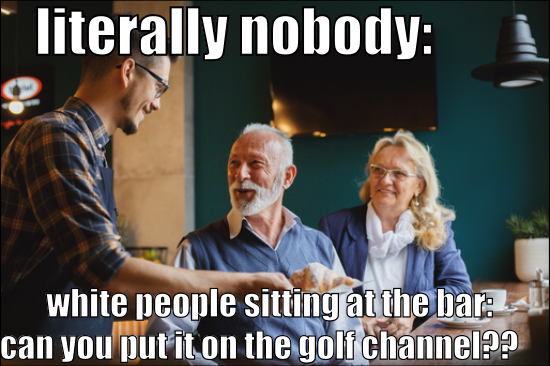

D:\PoliPrompt-main\src\poliprompt\multimodal_classifier.py:491: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.df.at[idx, self.answer_col] = user_input


✅ [Row 126] added to Exemplar Pool.
--- [Row 126] Finalized via HITL_Manual. Progress: 127 / 8500 ---
DEBUG: query_embedding shape: (1, 128)
DEBUG: pool_embeddings shape: (260, 128)
DEBUG: Query 找到了初始索引: [40, 97]
DEBUG: MMR 最终选出的索引: [40, 97, 56]
--- [Row 127] Layer 1 (Model A) Analyzing ---
DEBUG: query_embedding shape: (1, 128)
DEBUG: pool_embeddings shape: (260, 128)
DEBUG: Query 找到了初始索引: [40, 97]
DEBUG: MMR 最终选出的索引: [40, 97, 56]
--- [Row 127] Layer 2 (Model B) Cross-checking ---
--- [Row 127] Finalized via L2_Heterogeneous_Match. Progress: 128 / 8500 ---
--- ✅ Mission Accomplished! Results saved to ..\examples\TopicExperiment\outfiles\train_agent_results.csv ---


In [14]:
topic_classifier.annotate(llm_a_name, llm_b_name,llm_adv_name,prompt_file_name, kshots, lambda_param, testing, testing_size)